4*2 이미지를 만드는 코드

Loaded circle2_1000_True_Oct11_17-40.csv
max p-value: 0.5840962078386455 at epoch 116/217
Loaded circle2_1000_False_Oct11_17-40.csv
max p-value: 0.662923263441964 at epoch 97/219
Loaded circle2_1000_False_Oct11_08-43.csv
max p-value: 0.4487969245453476 at epoch 51/300
Loaded circle2_1000_True_Oct11_08-43.csv
max p-value: 0.1075212102163274 at epoch 45/300
Loaded circle2_1000_True_Oct10_16-41.csv
max p-value: 0.5233226309927725 at epoch 266/300
Loaded circle2_1000_False_Oct10_16-41.csv
max p-value: 0.3538545811569484 at epoch 155/300
Loaded circle2_1000_False_Oct10_09-13.csv
max p-value: 0.5858703174388604 at epoch 168/300
Loaded circle2_1000_True_Oct10_09-13.csv
max p-value: 0.4719752491809413 at epoch 211/300
Loaded circle2_1000_True_Oct09_23-34.csv
max p-value: 0.4688865213716346 at epoch 56/300
Loaded circle2_1000_False_Oct09_23-33.csv
max p-value: 0.3393820883034403 at epoch 36/300
Loaded circle2_1000_True_Oct09_19-12.csv
max p-value: p_value at epoch epoch/501
Data files for epoch

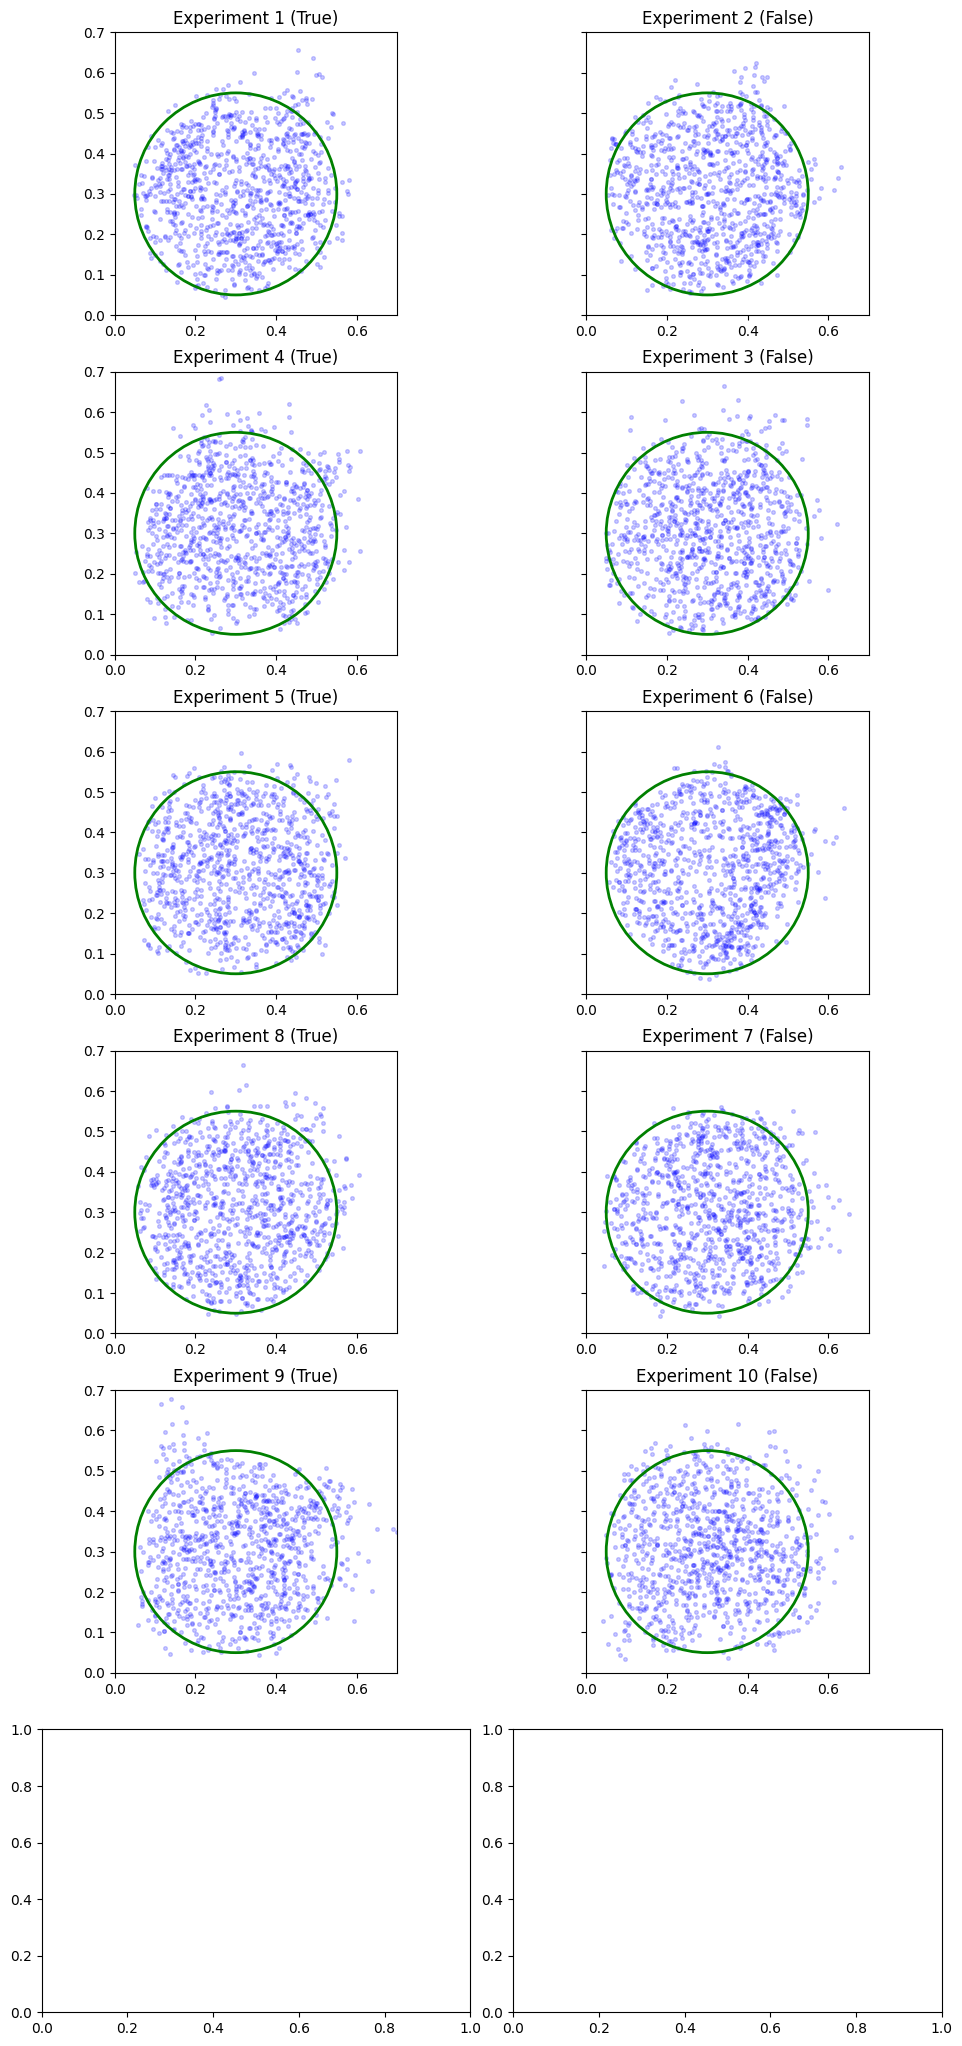

In [17]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

result_dir = "../runs"
experiment_names = [ 
    "circle2_1000_True_Oct11_17-40", "circle2_1000_False_Oct11_17-40",
    "circle2_1000_False_Oct11_08-43", "circle2_1000_True_Oct11_08-43",
    "circle2_1000_True_Oct10_16-41", "circle2_1000_False_Oct10_16-41",
    "circle2_1000_False_Oct10_09-13", "circle2_1000_True_Oct10_09-13",
    "circle2_1000_True_Oct09_23-34", "circle2_1000_False_Oct09_23-33",
    "circle2_1000_True_Oct09_19-12", "circle2_1000_False_Oct09_19-11"
]

# True와 False 실험별로 인덱스를 관리합니다.
true_idx = 0
false_idx = 0

# 전체 figure와 axes를 생성합니다.
fig, axes = plt.subplots(6, 2, figsize=(10, 22), gridspec_kw={'wspace': 0.1})

for idx, experiment_name in enumerate(experiment_names):
    experiment_path = os.path.join(result_dir, experiment_name, f"{experiment_name}.csv")

    df = None
    if os.path.exists(experiment_path):
        # 파일이 존재하면 읽어옵니다.
        df = pd.read_csv(experiment_path)
        print(f"Loaded {experiment_name}.csv")
    else:
        # 파일이 없으면 'scalars.csv'를 시도합니다.
        scalars_path = os.path.join(result_dir, experiment_name, "scalars.csv")
        if os.path.exists(scalars_path):
            df = pd.read_csv(scalars_path)
            print(f"{experiment_name}.csv not found. Loaded scalars.csv instead.")
        else:
            print(f"Neither {experiment_name}.csv nor scalars.csv found.")
            continue  # 파일이 없으면 다음 실험으로 넘어갑니다.

    max_p_value = df["p_value"].max()
    epoch_max_p_value = df[df["p_value"] == max_p_value]["epoch"].iloc[0]
    print(f"max p-value: {max_p_value} at epoch {epoch_max_p_value}/{len(df)}")

    # 데이터 파일 경로 설정
    outputs_path = os.path.join(result_dir, experiment_name, f"numpy/gen_outputs_epoch_{epoch_max_p_value}.txt")

    # 데이터가 존재하는지 확인
    if not os.path.exists(outputs_path):
        print(f"Data files for epoch {epoch_max_p_value} not found in {outputs_path}.")
        continue  # 데이터가 없으면 다음 실험으로 넘어갑니다.

    # 데이터 로드
    outputs = np.loadtxt(outputs_path)

    # 플롯할 축 선택
    if "True" in experiment_name:
        row_idx = true_idx
        col_idx = 0  # 왼쪽 열은 True 실험
        true_idx += 1
        exp_type = "True"
    else:
        row_idx = false_idx
        col_idx = 1  # 오른쪽 열은 False 실험
        false_idx += 1
        exp_type = "False"

    ax = axes[row_idx, col_idx]

    # 단색으로 플롯 (파란색 점)
    ax.scatter(outputs[:, 0], outputs[:, 1], color='blue', s=7, alpha=0.2)
    ax.set_title(f'Experiment {idx+1} ({exp_type})')

    ax.set_xlim(0, 0.7)
    ax.set_ylim(0, 0.7)
    ax.set_aspect('equal')

    # y축 레이블 제거 (오른쪽 열에 대해서만)
    if col_idx == 1:
        ax.tick_params(labelleft=False)

    # 중심 (0.3, 0.3), 반지름 0.25인 원 추가
    circle = patches.Circle((0.3, 0.3), 0.25, linewidth=2, edgecolor='green', facecolor='none')
    ax.add_patch(circle)

# 레이아웃 조정 및 이미지 저장
fig.subplots_adjust(left=0.05, right=0.95, top=0.95, bottom=0.05)

# 현재 경로에도 사진 저장
fig.savefig("experiments_no_colorbar.png")

plt.show()


In [18]:
import os
import csv

def remove_duplicate_headers(file_path):
    # 데이터를 저장할 리스트
    rows = []

    # 중복된 헤더를 제거하기 위해 첫 번째 줄을 헤더로 간주
    with open(file_path, 'r', encoding='utf-8') as infile:
        csvreader = csv.reader(infile)
        header = next(csvreader)  # 첫 번째 헤더 읽기
        rows.append(header)       # 헤더를 rows에 추가

        # 중복되지 않은 나머지 데이터를 rows에 추가
        for row in csvreader:
            if row == header:
                continue  # 중복된 헤더 건너뛰기
            rows.append(row)

    # 동일한 파일 경로에 새로 작성
    with open(file_path, 'w', newline='', encoding='utf-8') as outfile:
        csvwriter = csv.writer(outfile)
        csvwriter.writerows(rows)  # 모든 데이터를 다시 파일에 쓰기


# 각 실험 파일에서 중복 헤더 제거
for experiment_name in experiment_names:
    experiment_path = os.path.join(result_dir, experiment_name, f"{experiment_name}.csv")
    remove_duplicate_headers(experiment_path)
